<a href="https://colab.research.google.com/github/janpeter19/BPL_TEST2_Fedbatch/blob/main/BPL_TEST2_Fedbatch_oms_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BPL_TEST2_Fedbatch script with OMSimulator

The key library OMSimulator is installed.

After the installation a small application BPL_TEST2_Fedbatch is loaded and run. You can continue with this example if you like.

In [ ]:
!lsb_release -a # Actual VM Ubuntu version used by Google

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 24.04.5 LTS
Release:	24.04
Codename:	noble


In [ ]:
!python --version

Python 3.13.15


In [ ]:
!pip install OMSimulator

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for OMSimulator: filename=omsimulator-3.0.0.post116-py3-none-any.whl size=1345325 sha256=04ee29e151fbd3f2b7696ab0dc141a061f1849f5b66a42ebbb1afa28cf60adbe
  Stored in directory: /root/.cache/pip/wheels/eb/b0/ee/5194adbcfe75a2efc0262c5c0377b28ecbc648628be707b5a4
Successfully built OMSimulator


In [ ]:
!pip install git+https://github.com/janpeter19/FMU_explore.git

  Cloning https://github.com/janpeter19/FMU_explore.git to /tmp/pip-req-build-r6wf0jqn
  Running command git clone --filter=blob:none --quiet https://github.com/janpeter19/FMU_explore.git /tmp/pip-req-build-r6wf0jqn
  Resolved https://github.com/janpeter19/FMU_explore.git to commit 33481e5f5bd29367593ed25706382173e85d9367
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fmu_explore: filename=fmu_explore-1.2.5-py3-none-any.whl size=29640 sha256=eb0cc4d692da37741e7fff717f0638b50d43a9c3dedb4f006d34d23fefb09bca
  Stored in directory: /tmp/pip-ephem-wheel-cache-j_42o9k9/wheels/98/33/d9/8669158b0d845b084c49212b2330ad684e92d7a9ac84fcea8d
Successfully built fmu_explore


# BPL_TEST2_Fedbatch setup


Now specific installation and the run simulations. Start with connecting to Github. Then upload the two files:

* FMU - BPL_TEST2_Fedbatch_linux_om_me.fmu
* Setup-file - BPL_TEST2_Fedbatch_oms_explore.py

In [ ]:
%%bash
git clone https://github.com/janpeter19/BPL_TEST2_Fedbatch

Cloning into 'BPL_TEST2_Batch'...


In [ ]:
%cd BPL_TEST2_Fedbatch

/content/BPL_TEST2_Batch


In [ ]:
# Import the application model and context variables
from BPL_TEST2_Fedbatch_oms import*

Linux - run FMU pre-compiled OpenModelica


In [ ]:
# Import the general FMU_explore functions ana adapt them to the application
from fmu_explore_oms import AdaptWith

Application = AdaptWith(parValue, parLocation, parCheck, \
                        fmu_model, fmu_process_diagram, \
                        MSL_usage, MSL_version, BPL_version, \
                        simulationTime, timeDiscreteStates, \
                        diagrams, ax, lines)

par = Application.par
init = Application.init
simu = Application.simu
show = Application.show

resetPen = Application.resetPen
process_diagram = Application.process_diagram

describe_MSL = Application.describe_MSL
FMU_explore_info = Application.FMU_explore_info
system_info = Application.system_info
SDG = Application.SDG

In [ ]:
run -i BPL_TEST2_Fedbatch_oms_explore.py


Model for the process has been setup. Key commands:
 - par()       - change of parameters and initial values
 - init()      - change initial values only
 - simu()      - simulate and plot
 - newplot()   - make a new plot
 - show()      - show plot from previous simulation
 - disp()      - display parameters and initial values from the last simulation
 - describe()  - describe culture, broth, parameters, variables with values/units

Note that both disp() and describe() takes values from the last simulation
and the command process_diagram() brings up the main configuration

Brief information about a command by help(), eg help(simu)
Key system information is listed with the command system_info()


In [ ]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [25/2.54, 20/2.54]

In [ ]:
import warnings
warnings.filterwarnings("ignore")

## BPL_TEST2_Fedbatch - demo

1.   List item
2.   List item



No processDiagram.png file in the FMU, but try the file on disk.


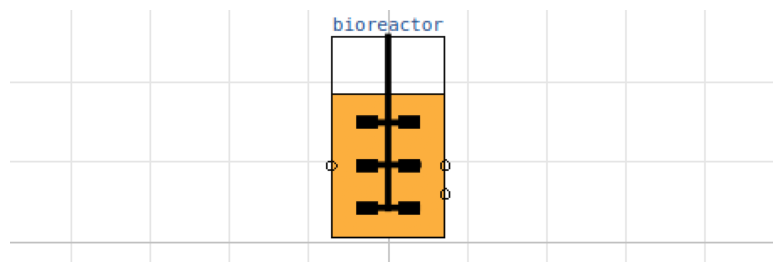

In [ ]:
process_diagram()

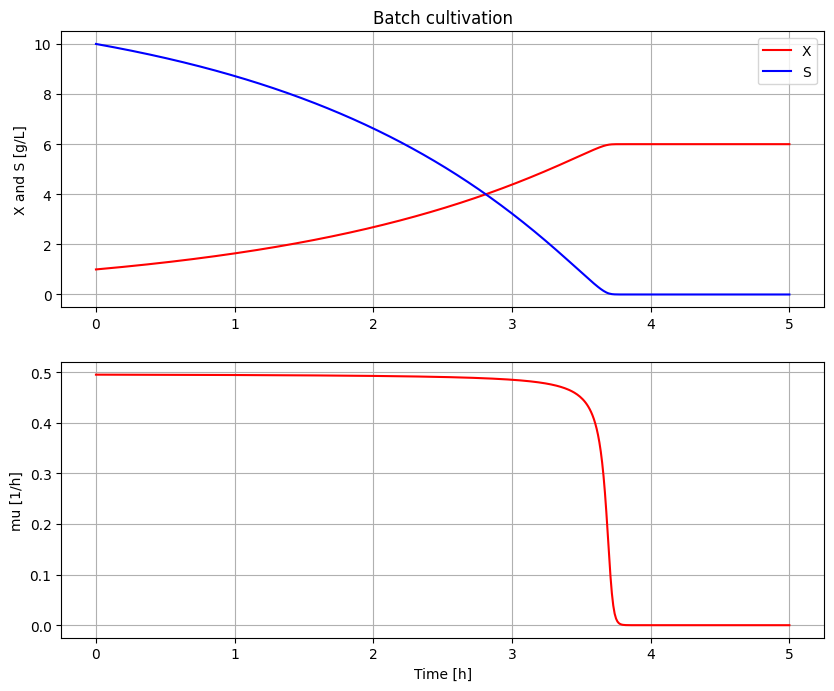

In [ ]:
# Simulation with default values of the process
newplot(plotType='TimeSeries')
simu()

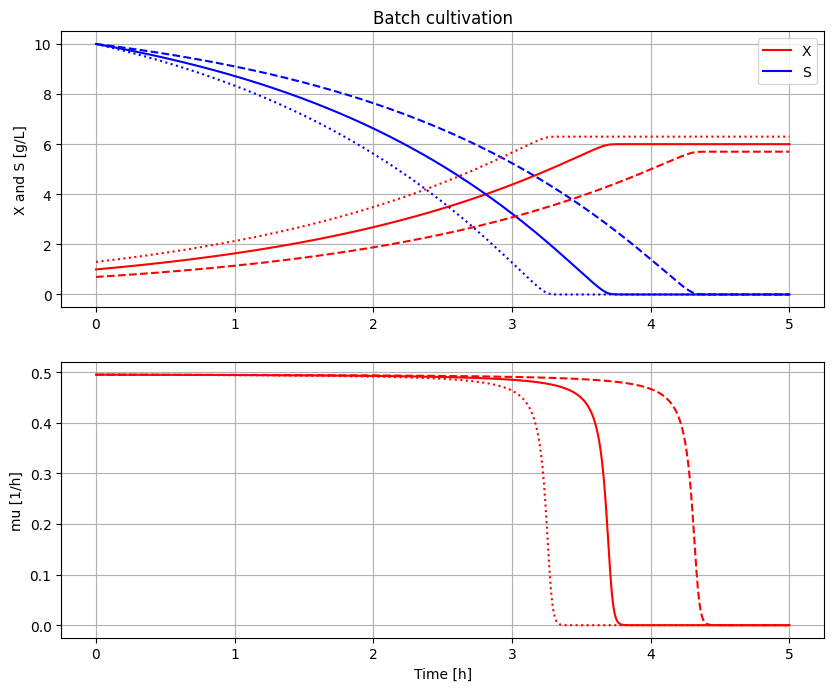

In [ ]:
# Simulation were initial value of biomass VX_0 is varied
newplot(plotType='TimeSeries')
for value in [1.0, 0.7, 1.3]:
  init(VX_start=value)
  simu()

# Restore default value of VX_start
init(VX_start=1.0)

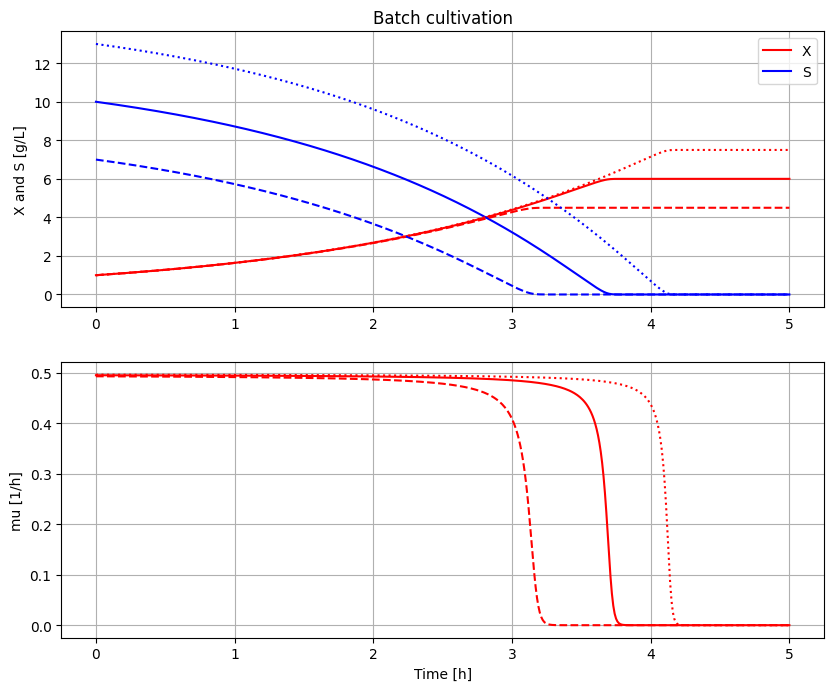

In [ ]:
# Simulation were initial value of substrate VS_0 is varied
newplot(plotType='TimeSeries')
for value in [10, 7, 13]:
  init(VS_start=value)
  simu()

# Restore default value of VS_start
init(VS_start=10)

In [ ]:
system_info()


System information
 -OS: Linux
 -Python: 3.13.15
 -Scipy: 1.16.3
 -OMSimulator: 3.0.0.post116
 -FMU by: OpenModelica Compiler OpenModelica 1.26.3~1-g7583224
 -FMI: 2.0
 -Type: me
 -Name: BPL.Examples_TEST2.Batch
 -Generated: 2026-04-11T11:35:27Z
 -MSL: 4.1.0
 -Description: Bioprocess Library version 2.3.2
 -Interaction: FMU_explore version 1.2.5


In [ ]:
!lsb_release -d

No LSB modules are available.
Description:	Ubuntu 24.04.5 LTS


In [ ]:
SDG()